# Step 13 — Dynamic Risk Trajectories

This analysis extends the fixed 2-hour landmark model into a dynamic
landmark framework.

Risk is estimated at 1, 2, 3, and 4 hours after ICU admission.

At each landmark:
- only information available up to that time is used;
- patients who have already deteriorated are excluded;
- deterioration during the following 6 hours is the prediction target.

The analysis is exploratory and uses the MIMIC-IV Demo dataset.
Predicted probabilities are not clinically validated risk scores.

ICU stays: 140
Outcome rows: 140
Chartevents: (668862, 11)

Outcome columns:
['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime', 'vasopressor_time_x', 'vasopressor_hours_from_icu', 'deathtime', 'hospital_expire_flag', 'icu_death', 'death_event_time', 'ventilation_time', 'ventilation_hours_from_icu', 'event_time', 'deterioration', 'event_type', 'hours_to_deterioration', 'vasopressor_time_y', 'vasopressor_time', 'landmark_time', 'prediction_end', 'reaches_landmark', 'event_before_landmark', 'eligible_at_landmark', 'deterioration_6_12h']
{'heart_rate': 220045, 'respiratory_rate': 220210, 'spo2': 220277, 'systolic_bp': 220179, 'diastolic_bp': 220180}
Selected vital measurements: 58062

variable
respiratory_rate    13913
heart_rate          13913
spo2                13540
diastolic_bp         8349
systolic_bp          8347
Name: count, dtype: int64
1h landmark: 108 stays | 27 events
2h landmark: 99 stays | 18 events
3h landmark: 89 stays | 9 events
4h landmark: 86 stays | 7 events
1h:

,landmark_hour,stays,patients,events,event_rate,event_rate_percent
0,1,108,83,27,0.25,25.00
1,2,99,79,18,0.18,18.18
2,3,89,71,9,0.10,10.11
3,4,86,68,7,0.08,8.14



Landmark 1h: 108 stays | 27 events

Landmark 2h: 99 stays | 18 events

Landmark 3h: 89 stays | 9 events

Landmark 4h: 86 stays | 7 events
Dynamic prediction rows: 382
Landmarks: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


,subject_id,hadm_id,stay_id,future_deterioration,landmark_hour,fold,risk_probability
0,10020740,25826145,32145159,0,1,1,0.143008
1,10027445,29163082,36084484,0,1,1,0.162664
2,10031404,21606243,35544374,0,1,1,0.194718
3,10029291,22205327,35146796,0,1,1,0.482562
4,10002930,25696644,37049133,0,1,1,0.155812


               stays  patients  events  mean_risk
landmark_hour                                    
1                108        83      27      0.419
2                 99        79      18      0.321
3                 89        71       9      0.225
4                 86        68       7      0.200
Stays with all four landmarks: 86
Stays with >=3 landmarks: 89
Candidate deteriorating stays: [30101877 30665396 31494479 32155744 32283063 32604416 33177122 33281088
 33383124 33558396]
Candidate non-deteriorating stays: [30057454 30458995 30585761 30849778 30864406 30876334 30913302 30932571
 30955999 31205490]


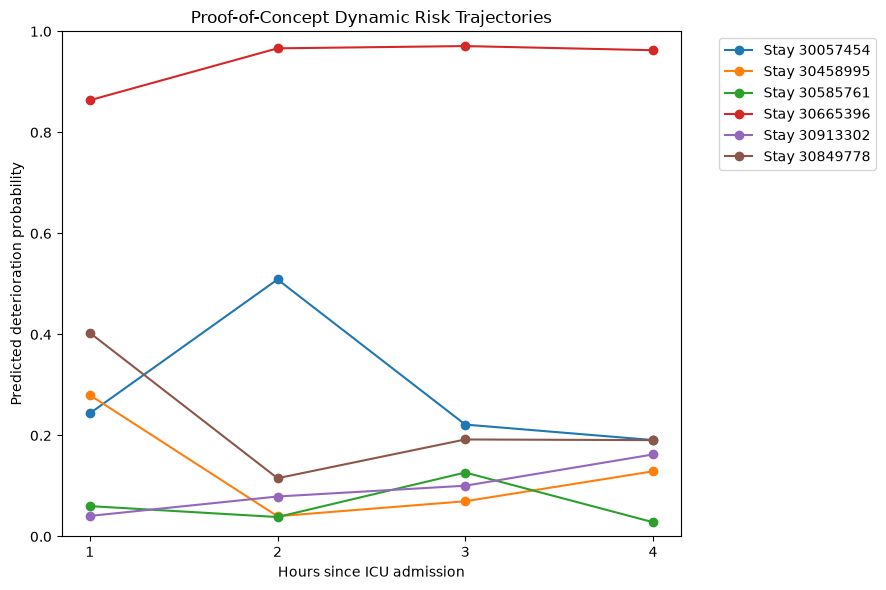

Dynamic trajectory datasets saved.
STEP 13 — DYNAMIC RISK TRAJECTORIES COMPLETE


,landmark_hour,stays,patients,events,event_rate_percent
0,1,108,83,27,25.00
1,2,99,79,18,18.18
2,3,89,71,9,10.11
3,4,86,68,7,8.14



Total dynamic predictions: 382
Unique ICU stays: 108
Stays with all four landmarks: 86
Stays with >=3 landmarks: 89

Patient-separated grouped CV used at each landmark.
Only information available up to each landmark was used.
Prediction horizon: next 6 hours.
Dynamic probabilities are exploratory and not clinically validated.


In [13]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

RESULTS_DIR = Path("../results")

icustays = pd.read_csv(
    "../data/icu/icustays.csv",
    parse_dates=["intime", "outtime"]
)

chartevents = pd.read_csv(
    "../data/icu/chartevents.csv",
    low_memory=False
)

outcomes = pd.read_csv(
    "../results/deterioration_outcomes.csv",
    parse_dates=["intime", "outtime", "event_time"]
)

print("ICU stays:", len(icustays))
print("Outcome rows:", len(outcomes))
print("Chartevents:", chartevents.shape)

print("\nOutcome columns:")
print(outcomes.columns.tolist())

VITAL_ITEMIDS = {
    "heart_rate": 220045,
    "respiratory_rate": 220210,
    "spo2": 220277,
    "systolic_bp": 220179,
    "diastolic_bp": 220180
}

print(VITAL_ITEMIDS)

vital_events = chartevents[
    chartevents["itemid"].isin(
        VITAL_ITEMIDS.values()
    )
].copy()

vital_events["charttime"] = pd.to_datetime(
    vital_events["charttime"]
)

vital_events["valuenum"] = pd.to_numeric(
    vital_events["valuenum"],
    errors="coerce"
)

item_to_name = {
    itemid: name
    for name, itemid in VITAL_ITEMIDS.items()
}

vital_events["variable"] = (
    vital_events["itemid"]
    .map(item_to_name)
)

vital_events = vital_events.dropna(
    subset=["valuenum", "charttime"]
)

print("Selected vital measurements:", len(vital_events))
print()
print(vital_events["variable"].value_counts())

LANDMARKS = [1, 2, 3, 4]
PREDICTION_HORIZON = 6

LANDMARKS = [1, 2, 3, 4]
PREDICTION_HORIZON = 6

base = outcomes[
    [
        "subject_id",
        "hadm_id",
        "stay_id",
        "intime",
        "outtime",
        "event_time"
    ]
].copy()

base["intime"] = pd.to_datetime(base["intime"])
base["outtime"] = pd.to_datetime(base["outtime"])
base["event_time"] = pd.to_datetime(base["event_time"])

dynamic_cohorts = {}

for landmark in LANDMARKS:

    temp = base.copy()

    temp["landmark_time"] = (
        temp["intime"]
        + pd.to_timedelta(landmark, unit="h")
    )

    temp["prediction_end"] = (
        temp["landmark_time"]
        + pd.to_timedelta(
            PREDICTION_HORIZON,
            unit="h"
        )
    )

    # Must still be in ICU at landmark
    temp = temp[
        temp["outtime"] > temp["landmark_time"]
    ].copy()

    # Exclude deterioration at/before landmark
    temp = temp[
        temp["event_time"].isna()
        |
        (temp["event_time"] > temp["landmark_time"])
    ].copy()

    # Future deterioration during next 6 hours
    temp["future_deterioration"] = (
        temp["event_time"].notna()
        &
        (temp["event_time"] <= temp["prediction_end"])
    ).astype(int)

    temp["landmark_hour"] = landmark

    dynamic_cohorts[landmark] = temp

    print(
        f"{landmark}h landmark:",
        len(temp),
        "stays |",
        int(temp["future_deterioration"].sum()),
        "events"
    )

    def extract_landmark_features(
    cohort,
    landmark_hour,
    vital_events
):

        merged = vital_events.merge(
        cohort[
            [
                "stay_id",
                "intime",
                "landmark_time"
            ]
        ],
        on="stay_id",
        how="inner"
    )

    def extract_landmark_features(cohort, landmark_hour, vital_events):
        merged = vital_events.merge(
            cohort[["stay_id", "intime", "landmark_time"]],
            on="stay_id",
            how="inner"
        )

        window = merged[
            (merged["charttime"] >= merged["intime"])
            & (merged["charttime"] <= merged["landmark_time"])
        ].copy()

        window = window.sort_values(
            ["stay_id", "variable", "charttime"]
        )

        grouped = window.groupby(
            ["stay_id", "variable"]
        )

        summary = grouped["valuenum"].agg(
            ["mean", "min", "max", "count"]
        )

        summary["last"] = grouped["valuenum"].last()

        wide = summary.unstack("variable")

        wide.columns = [
            f"{variable}_{stat}"
            for stat, variable in wide.columns
        ]

        wide = wide.reset_index()

        return cohort[
            [
                "subject_id",
                "hadm_id",
                "stay_id",
                "future_deterioration",
                "landmark_hour"
            ]
        ].merge(
            wide,
            on="stay_id",
            how="left"
        )


    dynamic_feature_sets = {}

    # Use the current landmark cohort, not the previous temporary dataframe.
    merged = vital_events.merge(
        dynamic_cohorts[landmark][
            ["stay_id", "intime", "landmark_time"]
        ],
        on="stay_id",
        how="inner"
    )

    window = merged[
        (merged["charttime"] >= merged["intime"])
        & (merged["charttime"] <= merged["landmark_time"])
    ].copy()

    window = window.sort_values(
        ["stay_id", "variable", "charttime"]
    )

    grouped = window.groupby(
        ["stay_id", "variable"]
    )

    summary = grouped["valuenum"].agg(
        ["mean", "min", "max", "count"]
    )

    summary["last"] = grouped["valuenum"].last()

    wide = summary.unstack("variable")

    wide.columns = [
        f"{variable}_{stat}"
        for stat, variable in wide.columns
    ]

    wide = wide.reset_index()

    def extract_landmark_features(cohort, landmark_hour, vital_events):
        merged = vital_events.merge(
            cohort[["stay_id", "intime", "landmark_time"]],
            on="stay_id",
            how="inner"
        )

        window = merged[
            (merged["charttime"] >= merged["intime"])
            & (merged["charttime"] <= merged["landmark_time"])
        ].copy()

        window = window.sort_values(
            ["stay_id", "variable", "charttime"]
        )

        grouped = window.groupby(["stay_id", "variable"])

        summary = grouped["valuenum"].agg(
            ["mean", "min", "max", "count"]
        )

        summary["last"] = grouped["valuenum"].last()

        wide = summary.unstack("variable")

        wide.columns = [
            f"{variable}_{stat}"
            for stat, variable in wide.columns
        ]

        wide = wide.reset_index()

        return cohort[
            [
                "subject_id",
                "hadm_id",
                "stay_id",
                "future_deterioration",
                "landmark_hour"
            ]
        ].merge(
            wide,
            on="stay_id",
            how="left"
        )


    dynamic_feature_sets = {}

    # Sort so "last" is truly the latest value
    window = window.sort_values(
        ["stay_id", "variable", "charttime"]
    )

    grouped = window.groupby(
        ["stay_id", "variable"]
    )

    summary = grouped["valuenum"].agg(
        ["mean", "min", "max", "count"]
    )

    last_values = grouped["valuenum"].last()

    summary["last"] = last_values

    wide = summary.unstack("variable")

    wide.columns = [
        f"{variable}_{stat}"
        for stat, variable in wide.columns
    ]

    wide = wide.reset_index()

    def extract_landmark_features(cohort, landmark_hour, vital_events):
        merged = vital_events.merge(
            cohort[["stay_id", "intime", "landmark_time"]],
            on="stay_id",
            how="inner"
        )

        window = merged[
            (merged["charttime"] >= merged["intime"])
            & (merged["charttime"] <= merged["landmark_time"])
        ].sort_values(
            ["stay_id", "variable", "charttime"]
        )

        if window.empty:
            features = cohort[
                [
                    "subject_id",
                    "hadm_id",
                    "stay_id",
                    "future_deterioration",
                    "landmark_hour"
                ]
            ].copy()
            return features

        grouped = window.groupby(
            ["stay_id", "variable"],
            sort=False
        )

        summary = grouped["valuenum"].agg(
            mean="mean",
            min="min",
            max="max",
            count="count",
            last="last"
        )

        wide = summary.unstack("variable")
        wide.columns = [
            f"{variable}_{stat}"
            for stat, variable in wide.columns
        ]
        wide = wide.reset_index()

        return cohort[
            [
                "subject_id",
                "hadm_id",
                "stay_id",
                "future_deterioration",
                "landmark_hour"
            ]
        ].merge(
            wide,
            on="stay_id",
            how="left"
        )

    def extract_landmark_features(cohort, landmark_hour, vital_events):
        merged = vital_events.merge(
            cohort[["stay_id", "intime", "landmark_time"]],
            on="stay_id",
            how="inner"
        )

        window = merged[
            (merged["charttime"] >= merged["intime"])
            & (merged["charttime"] <= merged["landmark_time"])
        ].copy()

        window = window.sort_values(
            ["stay_id", "variable", "charttime"]
        )

        grouped = window.groupby(["stay_id", "variable"])

        summary = grouped["valuenum"].agg(
            ["mean", "min", "max", "count"]
        )

        summary["last"] = grouped["valuenum"].last()

        wide = summary.unstack("variable")
        wide.columns = [
            f"{variable}_{stat}"
            for stat, variable in wide.columns
        ]

        wide = wide.reset_index()

        return cohort[
            [
                "subject_id",
                "hadm_id",
                "stay_id",
                "future_deterioration",
                "landmark_hour"
            ]
        ].merge(
            wide,
            on="stay_id",
            how="left"
        )

    dynamic_feature_sets = {}

for landmark in LANDMARKS:

    dynamic_feature_sets[landmark] = (
        extract_landmark_features(
            dynamic_cohorts[landmark],
            landmark,
            vital_events
        )
    )

    temp = dynamic_feature_sets[landmark]

    print(
        f"{landmark}h:",
        temp.shape,
        "| events:",
        temp["future_deterioration"].sum()
    )

    NON_FEATURES = [
    "subject_id",
    "hadm_id",
    "stay_id",
    "future_deterioration",
    "landmark_hour"
]

feature_sets = []

for landmark, temp in dynamic_feature_sets.items():

    feature_sets.append(
        set(temp.columns) - set(NON_FEATURES)
    )

common_features = sorted(
    set.intersection(*feature_sets)
)

print("Common dynamic predictors:")
print(len(common_features))
print(common_features)

landmark_summary = []

for landmark, temp in dynamic_feature_sets.items():

    landmark_summary.append({
        "landmark_hour": landmark,
        "stays": len(temp),
        "patients":
            temp["subject_id"].nunique(),
        "events":
            int(
                temp[
                    "future_deterioration"
                ].sum()
            ),
        "event_rate":
            temp[
                "future_deterioration"
            ].mean()
    })

landmark_summary = pd.DataFrame(
    landmark_summary
)

landmark_summary["event_rate_percent"] = (
    landmark_summary["event_rate"] * 100
)

display(
    landmark_summary.round(2)
)

all_dynamic_predictions = []

for landmark in LANDMARKS:

    temp = dynamic_feature_sets[landmark].copy()

    X = temp[common_features]
    y = temp["future_deterioration"]
    groups = temp["subject_id"]

    print(
        f"\nLandmark {landmark}h:",
        len(temp),
        "stays |",
        int(y.sum()),
        "events"
    )

    # Need enough events for CV
    if y.sum() < 3:
        print(
            "Skipped: fewer than 3 positive outcomes."
        )
        continue

    cv = StratifiedGroupKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    fold_predictions = []

    for fold, (train_idx, test_idx) in enumerate(
        cv.split(X, y, groups),
        start=1
    ):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]

        model = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=100,
                    max_depth=4,
                    min_samples_leaf=3,
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=-1
                )
            )
        ])

        model.fit(
            X_train,
            y_train
        )

        probability = (
            model.predict_proba(X_test)[:, 1]
        )

        fold_df = temp.iloc[
            test_idx
        ][
            [
                "subject_id",
                "hadm_id",
                "stay_id",
                "future_deterioration"
            ]
        ].copy()

        fold_df["landmark_hour"] = landmark
        fold_df["fold"] = fold
        fold_df["risk_probability"] = probability

        fold_predictions.append(
            fold_df
        )

    landmark_predictions = pd.concat(
        fold_predictions,
        ignore_index=True
    )

    all_dynamic_predictions.append(
        landmark_predictions
    )

    dynamic_predictions = pd.concat(
    all_dynamic_predictions,
    ignore_index=True
)

print(
    "Dynamic prediction rows:",
    len(dynamic_predictions)
)

print(
    "Landmarks:",
    sorted(
        dynamic_predictions[
            "landmark_hour"
        ].unique()
    )
)

display(
    dynamic_predictions.head()
)

print(
    dynamic_predictions
    .groupby("landmark_hour")
    .agg(
        stays=("stay_id", "nunique"),
        patients=("subject_id", "nunique"),
        events=(
            "future_deterioration",
            "sum"
        ),
        mean_risk=(
            "risk_probability",
            "mean"
        )
    )
    .round(3)
)

trajectory_counts = (
    dynamic_predictions
    .groupby("stay_id")
    ["landmark_hour"]
    .nunique()
    .sort_values(
        ascending=False
    )
)

print(
    "Stays with all four landmarks:",
    (trajectory_counts == 4).sum()
)

print(
    "Stays with >=3 landmarks:",
    (trajectory_counts >= 3).sum()
)

trajectory_data = (
    dynamic_predictions
    .sort_values(
        ["stay_id", "landmark_hour"]
    )
)

deteriorating_stays = (
    trajectory_data[
        trajectory_data[
            "future_deterioration"
        ] == 1
    ]["stay_id"]
    .unique()
)

non_deteriorating_stays = (
    trajectory_data[
        trajectory_data[
            "future_deterioration"
        ] == 0
    ]["stay_id"]
    .unique()
)

print(
    "Candidate deteriorating stays:",
    deteriorating_stays[:10]
)

print(
    "Candidate non-deteriorating stays:",
    non_deteriorating_stays[:10]
)

complete_stays = (
    trajectory_counts[
        trajectory_counts >= 3
    ]
    .index
    .tolist()
)

plot_stays = complete_stays[:6]

plt.figure(figsize=(9, 6))

for stay in plot_stays:

    patient = trajectory_data[
        trajectory_data["stay_id"] == stay
    ]

    plt.plot(
        patient["landmark_hour"],
        patient["risk_probability"],
        marker="o",
        label=f"Stay {stay}"
    )

plt.xlabel(
    "Hours since ICU admission"
)

plt.ylabel(
    "Predicted deterioration probability"
)

plt.title(
    "Proof-of-Concept Dynamic Risk Trajectories"
)

plt.ylim(0, 1)

plt.xticks(LANDMARKS)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

dynamic_predictions.to_csv(
    RESULTS_DIR /
    "dynamic_risk_predictions.csv",
    index=False
)

landmark_summary.to_csv(
    RESULTS_DIR /
    "dynamic_landmark_summary.csv",
    index=False
)

print(
    "Dynamic trajectory datasets saved."
)

print("=" * 65)
print("STEP 13 — DYNAMIC RISK TRAJECTORIES COMPLETE")
print("=" * 65)

display(
    landmark_summary[
        [
            "landmark_hour",
            "stays",
            "patients",
            "events",
            "event_rate_percent"
        ]
    ].round(2)
)

print(
    "\nTotal dynamic predictions:",
    len(dynamic_predictions)
)

print(
    "Unique ICU stays:",
    dynamic_predictions[
        "stay_id"
    ].nunique()
)

print(
    "Stays with all four landmarks:",
    (trajectory_counts == 4).sum()
)

print(
    "Stays with >=3 landmarks:",
    (trajectory_counts >= 3).sum()
)

print(
    "\nPatient-separated grouped CV used at each landmark."
)

print(
    "Only information available up to each landmark was used."
)

print(
    "Prediction horizon: next 6 hours."
)

print(
    "Dynamic probabilities are exploratory and not clinically validated."
)